# Import Libraries

In [40]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder ,StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Data set

In [2]:
df = pd.read_csv("risk_dataset.csv")

In [3]:
df

,Risk,Income,Debt,Credit Score,Payment History,Loan Amount,Employment Status,Age,Number of Credit,Loan Tenure,Default History
0,Bad,36578,51714,402,Average,1169,Employed,58,1,57,No
1,Good,53110,53153,735,Poor,5951,Self-Employed,51,1,35,No
2,Bad,93296,50591,570,Poor,2096,Employed,56,4,38,No
3,Good,98542,8047,406,Good,7882,Employed,39,6,57,No
4,Bad,26488,74831,371,Good,4870,Employed,56,8,14,No
...,...,...,...,...,...,...,...,...,...,...,...
995,Good,67053,20074,655,Good,1736,Employed,33,4,16,No
996,Bad,39079,60841,340,Good,3857,Employed,28,9,37,No
997,Good,84223,39702,333,Good,804,Employed,60,4,54,No
998,Good,93497,13594,316,Average,1845,Employed,24,5,12,No


In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Risk               1000 non-null   object
 1   Income             1000 non-null   int64 
 2   Debt               1000 non-null   int64 
 3   Credit Score       1000 non-null   int64 
 4   Payment History    1000 non-null   object
 5   Loan Amount        1000 non-null   int64 
 6   Employment Status  1000 non-null   object
 7   Age                1000 non-null   int64 
 8   Number of Credit   1000 non-null   int64 
 9   Loan Tenure        1000 non-null   int64 
 10  Default History    1000 non-null   object
dtypes: int64(7), object(4)
memory usage: 86.1+ KB


In [5]:
print(df.head())


   Risk  Income   Debt  Credit Score Payment History  Loan Amount  \
0   Bad   36578  51714           402         Average         1169   
1  Good   53110  53153           735            Poor         5951   
2   Bad   93296  50591           570            Poor         2096   
3  Good   98542   8047           406            Good         7882   
4   Bad   26488  74831           371            Good         4870   

  Employment Status  Age  Number of Credit  Loan Tenure Default History  
0          Employed   58                 1           57              No  
1     Self-Employed   51                 1           35              No  
2          Employed   56                 4           38              No  
3          Employed   39                 6           57              No  
4          Employed   56                 8           14              No  


In [6]:
print("\nDataset Shape:")
print(df.shape)


Dataset Shape:
(1000, 11)


In [7]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Risk               1000 non-null   object
 1   Income             1000 non-null   int64 
 2   Debt               1000 non-null   int64 
 3   Credit Score       1000 non-null   int64 
 4   Payment History    1000 non-null   object
 5   Loan Amount        1000 non-null   int64 
 6   Employment Status  1000 non-null   object
 7   Age                1000 non-null   int64 
 8   Number of Credit   1000 non-null   int64 
 9   Loan Tenure        1000 non-null   int64 
 10  Default History    1000 non-null   object
dtypes: int64(7), object(4)
memory usage: 86.1+ KB
None


# EDA (Exploratory Data Analysis)

In [8]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Risk                 0
Income               0
Debt                 0
Credit Score         0
Payment History      0
Loan Amount          0
Employment Status    0
Age                  0
Number of Credit     0
Loan Tenure          0
Default History      0
dtype: int64


In [9]:
# Duplicate Values
print(df.duplicated().sum())

0


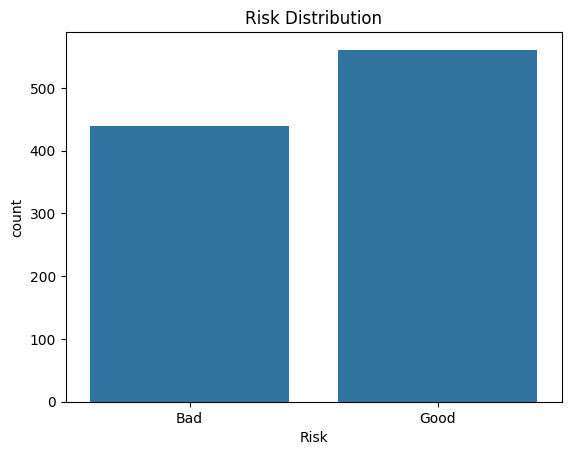

In [10]:
# Count Plot
sns.countplot(x='Risk', data=df)
plt.title("Risk Distribution")
plt.show()

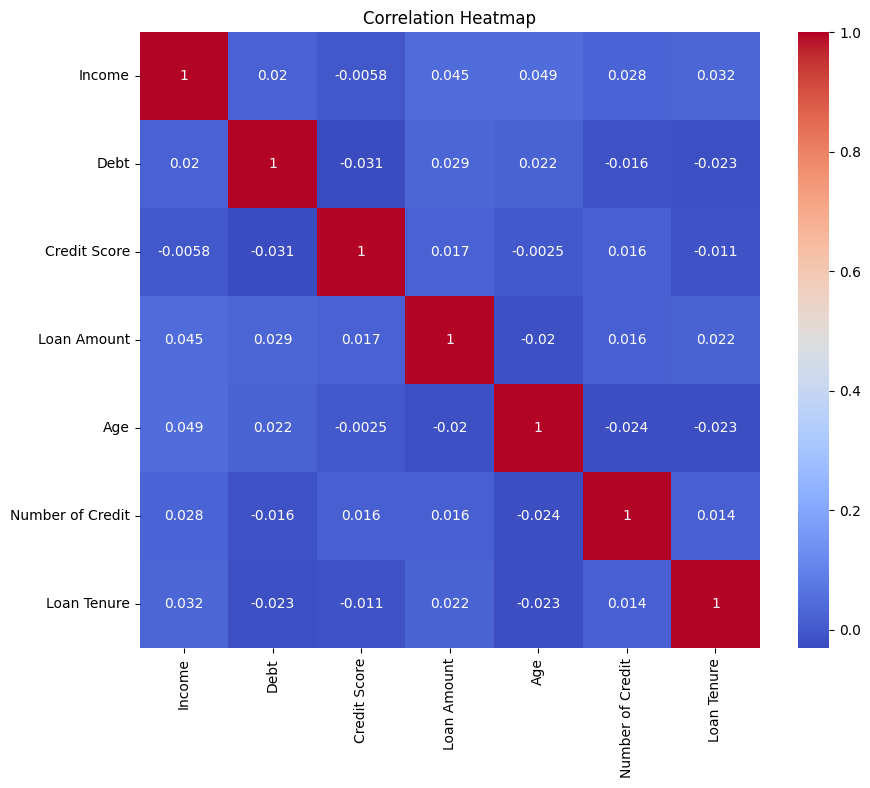

In [11]:
plt.figure(figsize=(10,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

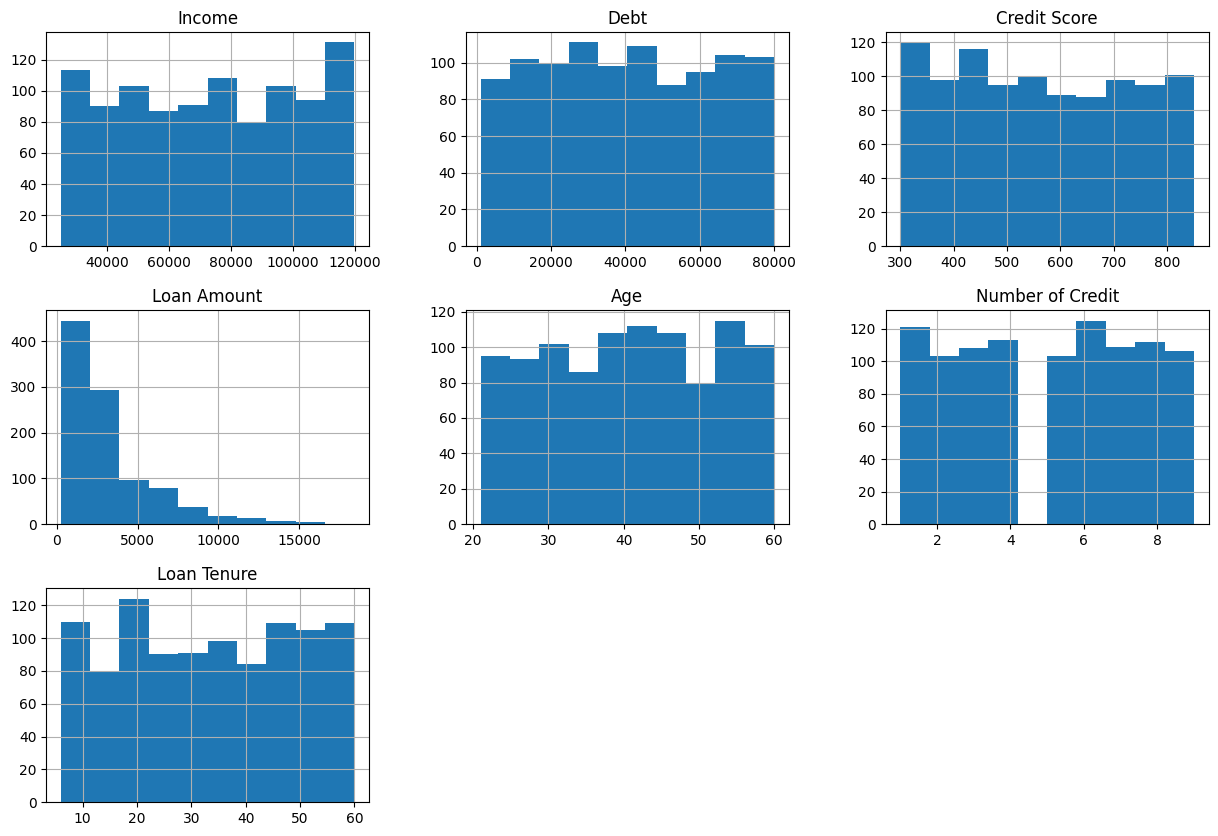

In [12]:
df.hist(figsize=(15,10))
plt.show()

In [13]:
print(df.columns)

Index(['Risk', 'Income', 'Debt', 'Credit Score', 'Payment History',
       'Loan Amount', 'Employment Status', 'Age', 'Number of Credit',
       'Loan Tenure', 'Default History'],
      dtype='object')


# Data Preprocessing

In [14]:
# Fill numerical missing values
for col in df.select_dtypes(include=np.number).columns:
    df[col] = df[col].fillna(df[col].mean())

# Fill categorical missing values
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

In [15]:
df

,Risk,Income,Debt,Credit Score,Payment History,Loan Amount,Employment Status,Age,Number of Credit,Loan Tenure,Default History
0,Bad,36578,51714,402,Average,1169,Employed,58,1,57,No
1,Good,53110,53153,735,Poor,5951,Self-Employed,51,1,35,No
2,Bad,93296,50591,570,Poor,2096,Employed,56,4,38,No
3,Good,98542,8047,406,Good,7882,Employed,39,6,57,No
4,Bad,26488,74831,371,Good,4870,Employed,56,8,14,No
...,...,...,...,...,...,...,...,...,...,...,...
995,Good,67053,20074,655,Good,1736,Employed,33,4,16,No
996,Bad,39079,60841,340,Good,3857,Employed,28,9,37,No
997,Good,84223,39702,333,Good,804,Employed,60,4,54,No
998,Good,93497,13594,316,Average,1845,Employed,24,5,12,No


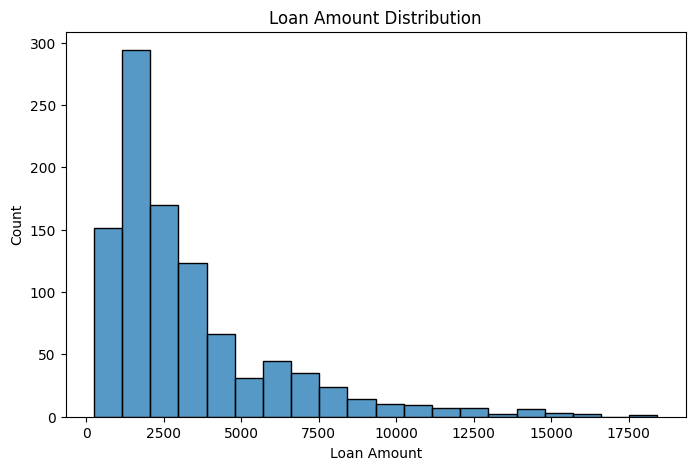

In [16]:

# Loan Amount Distribution

plt.figure(figsize=(8,5))

sns.histplot(df["Loan Amount"], bins=20)

plt.title("Loan Amount Distribution")

plt.xlabel("Loan Amount")

plt.show()


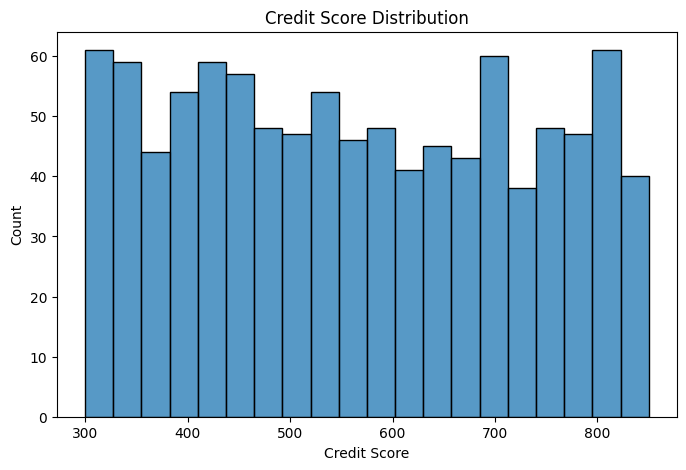

<Axes: xlabel='Income', ylabel='Debt'>

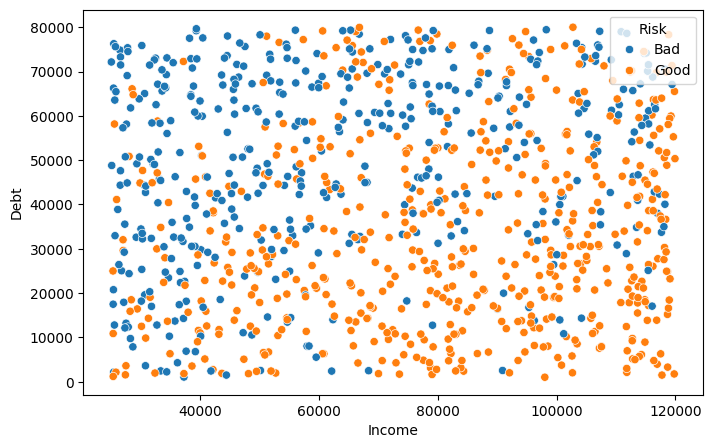

In [17]:
# ==========================================
# Credit Score Distribution
# ==========================================

plt.figure(figsize=(8,5))

sns.histplot(df["Credit Score"], bins=20)

plt.title("Credit Score Distribution")

plt.xlabel("Credit Score")

plt.show()

# ==========================================
# Income vs Debt
# ==========================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["Income"],
    y=df["Debt"],
    hue=df["Risk"]
)

# LabelEncode

In [18]:
label_encoder = LabelEncoder()

categorical_columns = [
    'Payment History',
    'Employment Status',
    'Default History',
    'Risk'
]

for col in categorical_columns:
    df[col] = label_encoder.fit_transform(df[col])


In [19]:
df


,Risk,Income,Debt,Credit Score,Payment History,Loan Amount,Employment Status,Age,Number of Credit,Loan Tenure,Default History
0,0,36578,51714,402,0,1169,0,58,1,57,0
1,1,53110,53153,735,2,5951,1,51,1,35,0
2,0,93296,50591,570,2,2096,0,56,4,38,0
3,1,98542,8047,406,1,7882,0,39,6,57,0
4,0,26488,74831,371,1,4870,0,56,8,14,0
...,...,...,...,...,...,...,...,...,...,...,...
995,1,67053,20074,655,1,1736,0,33,4,16,0
996,0,39079,60841,340,1,3857,0,28,9,37,0
997,1,84223,39702,333,1,804,0,60,4,54,0
998,1,93497,13594,316,0,1845,0,24,5,12,0


# StandardScaler

In [20]:
numeric_df = df.select_dtypes(include=np.number)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)
scaled_df = pd.DataFrame(
    scaled_data,
   columns=numeric_df.columns
)
scaled_df.head()

,Risk,Income,Debt,Credit Score,Payment History,Loan Amount,Employment Status,Age,Number of Credit,Loan Tenure,Default History
0,-1.130444,-1.291468,0.494552,-1.012067,-1.268727,-0.745131,-0.582583,1.498432,-1.541145,1.489298,-0.509358
1,0.884608,-0.710344,0.557875,1.056837,1.209255,0.949817,0.975125,0.886613,-1.541145,0.112289,-0.509358
2,-1.130444,0.702253,0.445135,0.031705,1.209255,-0.416562,-0.582583,1.323626,-0.379770,0.300063,-0.509358
3,0.884608,0.886657,-1.427001,-0.987215,-0.029736,1.634247,-0.582583,-0.162219,0.394480,1.489298,-0.509358
4,-1.130444,-1.646146,1.511809,-1.204668,-0.029736,0.566664,-0.582583,1.323626,1.168730,-1.202129,-0.509358


# Feature Engineering

In [21]:
# Example Feature Engineering

df['Income_to_Loan'] = df['Income'] / (df['Loan Amount'] + 1)

df['Debt_to_Income'] = df['Debt'] / (df['Income'] + 1)

print(df.head())

   Risk  Income   Debt  Credit Score  Payment History  Loan Amount  \
0     0   36578  51714           402                0         1169   
1     1   53110  53153           735                2         5951   
2     0   93296  50591           570                2         2096   
3     1   98542   8047           406                1         7882   
4     0   26488  74831           371                1         4870   

   Employment Status  Age  Number of Credit  Loan Tenure  Default History  \
0                  0   58                 1           57                0   
1                  1   51                 1           35                0   
2                  0   56                 4           38                0   
3                  0   39                 6           57                0   
4                  0   56                 8           14                0   

   Income_to_Loan  Debt_to_Income  
0       31.263248        1.413762  
1        8.923051        1.000791  
2       

# Train-Test Split

In [22]:
X = df.drop("Risk", axis=1)
y = df["Risk"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


In [23]:
df


,Risk,Income,Debt,Credit Score,Payment History,Loan Amount,Employment Status,Age,Number of Credit,Loan Tenure,Default History,Income_to_Loan,Debt_to_Income
0,0,36578,51714,402,0,1169,0,58,1,57,0,31.263248,1.413762
1,1,53110,53153,735,2,5951,1,51,1,35,0,8.923051,1.000791
2,0,93296,50591,570,2,2096,0,56,4,38,0,44.490224,0.542258
3,1,98542,8047,406,1,7882,0,39,6,57,0,12.500571,0.081660
4,0,26488,74831,371,1,4870,0,56,8,14,0,5.437898,2.824984
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,67053,20074,655,1,1736,0,33,4,16,0,38.602763,0.299371
996,0,39079,60841,340,1,3857,0,28,9,37,0,10.129342,1.556832
997,1,84223,39702,333,1,804,0,60,4,54,0,104.624845,0.471386
998,1,93497,13594,316,0,1845,0,24,5,12,0,50.648429,0.145393


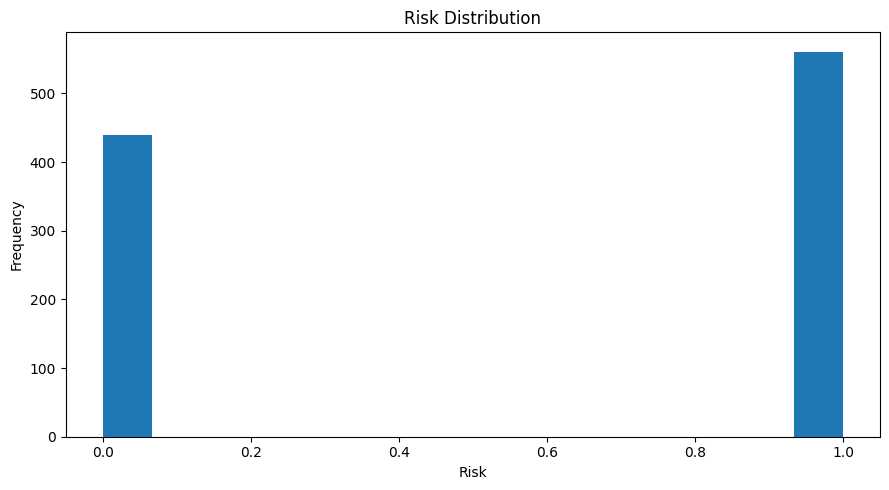

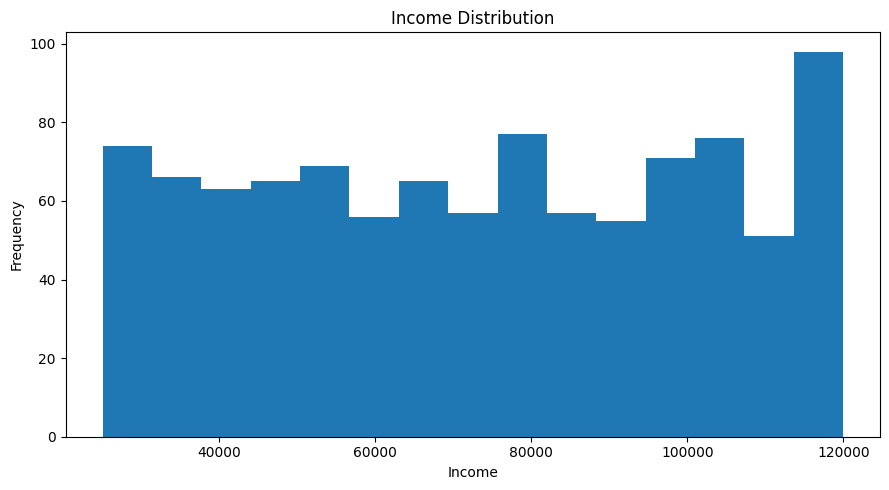

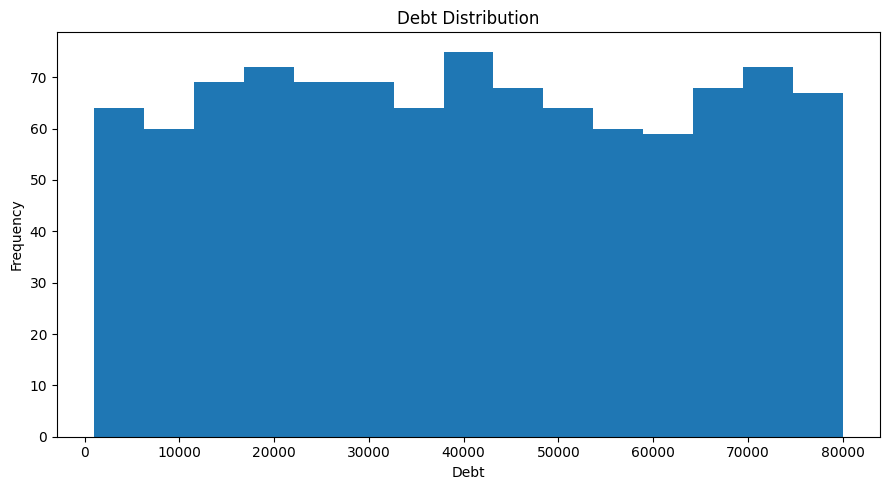

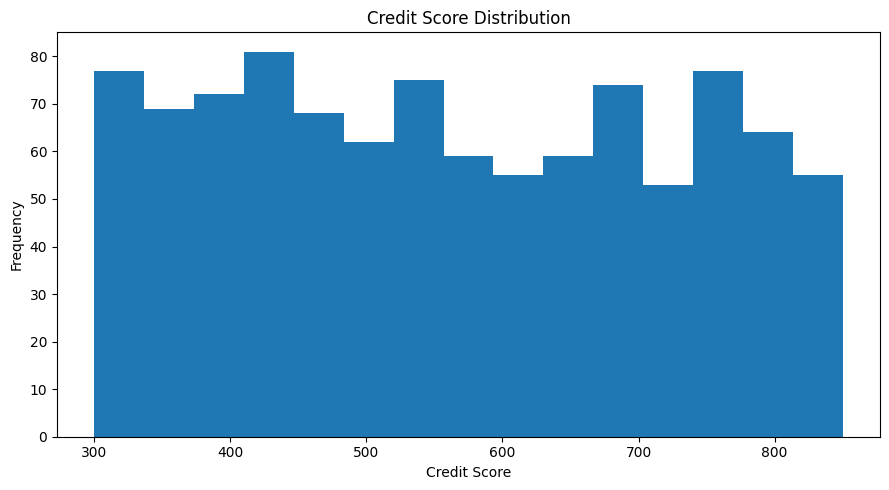

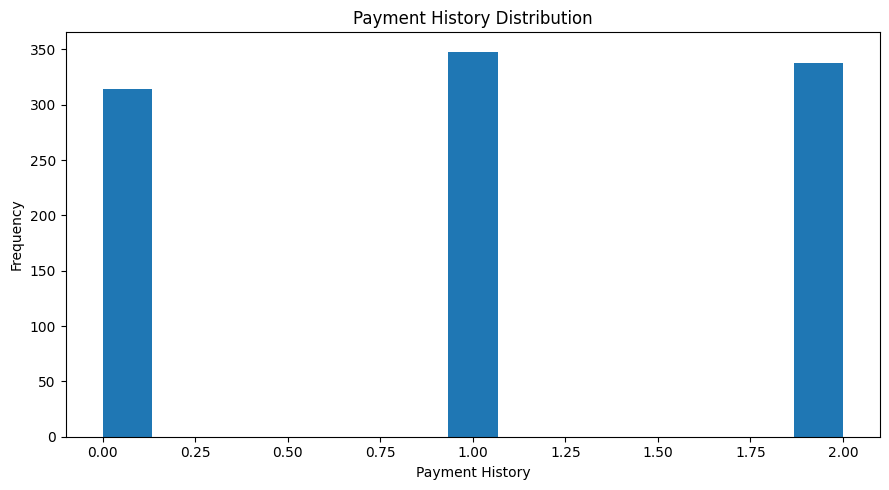

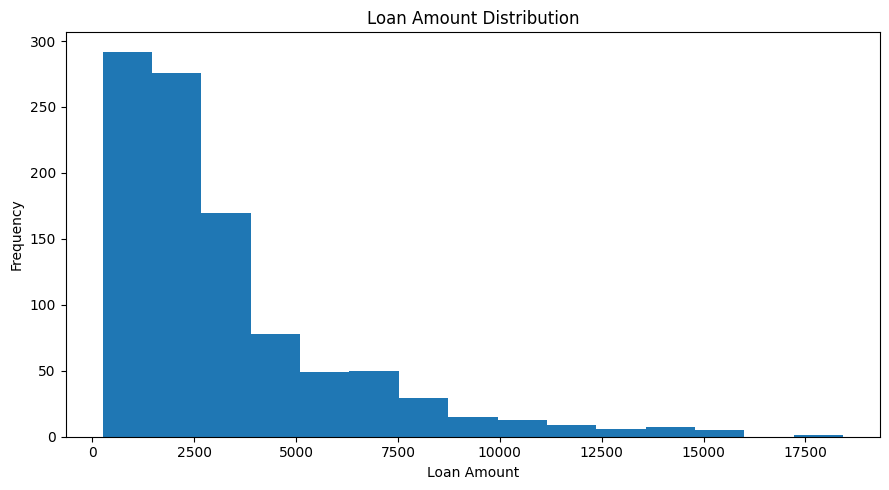

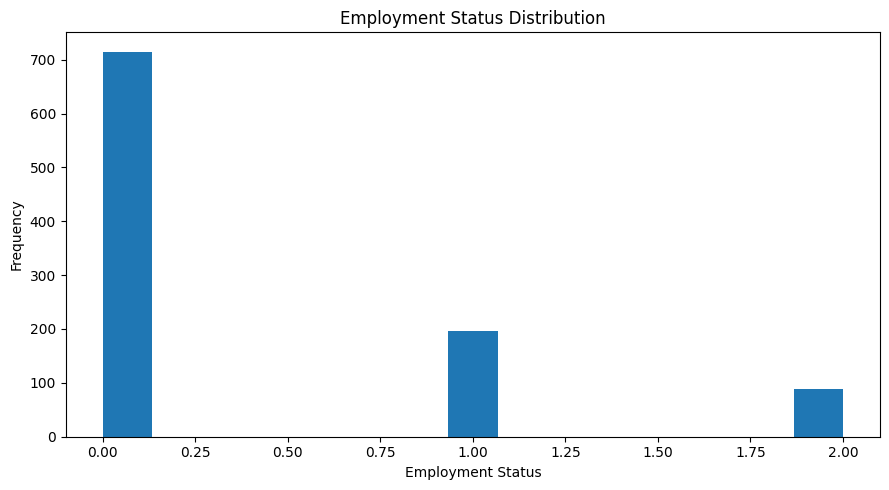

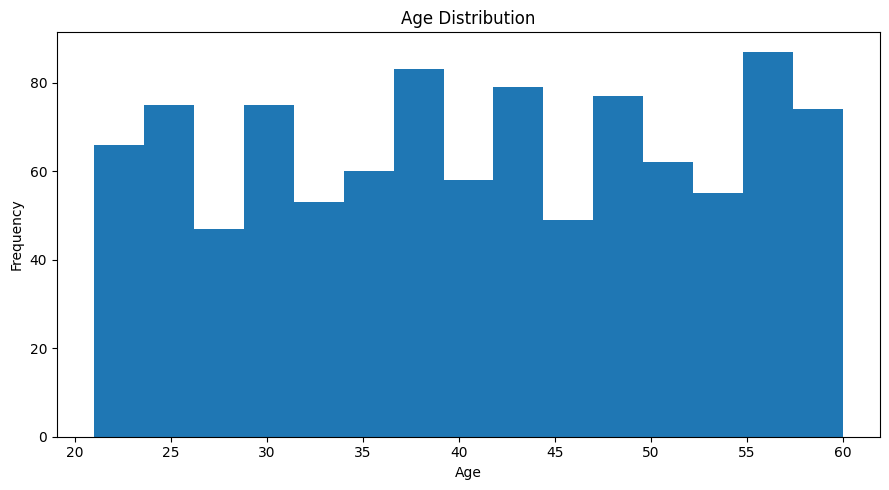

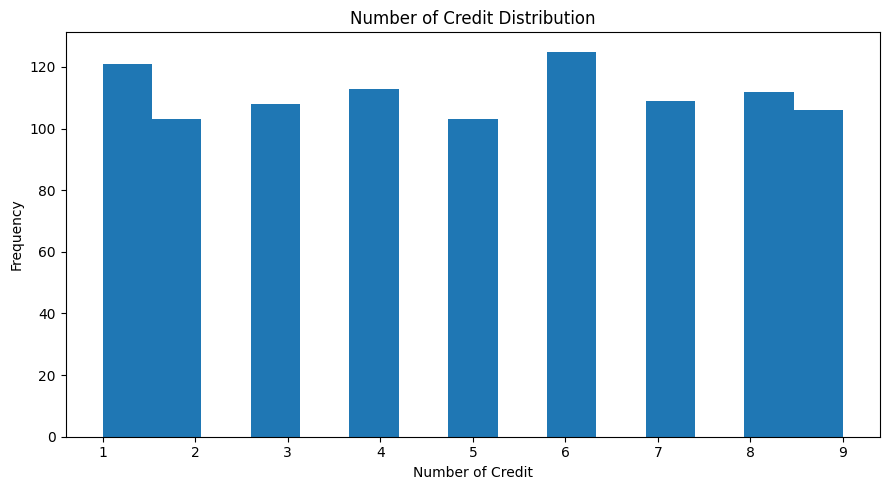

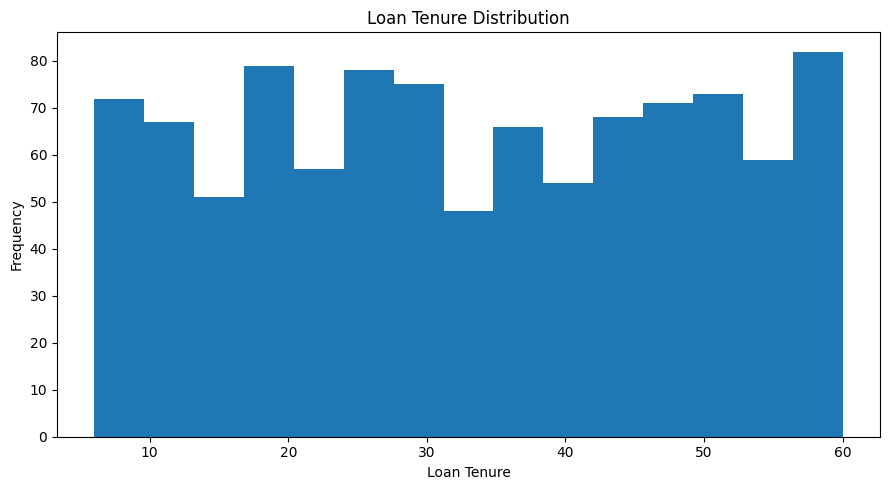

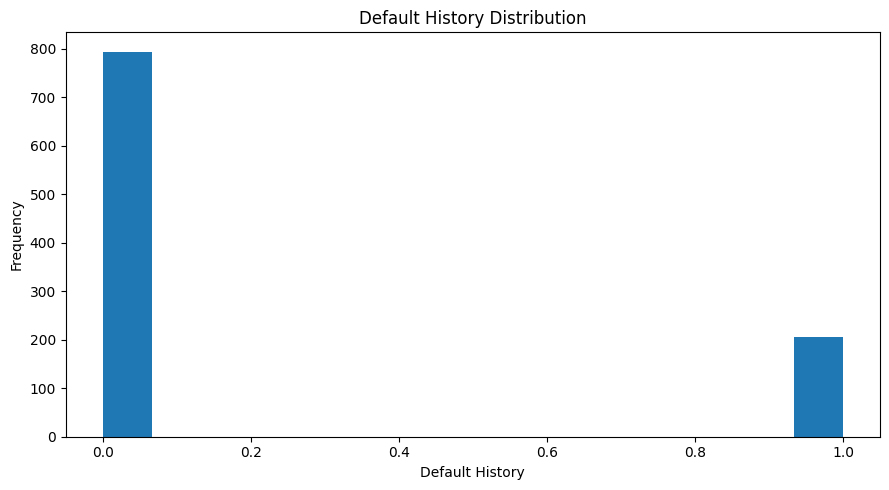

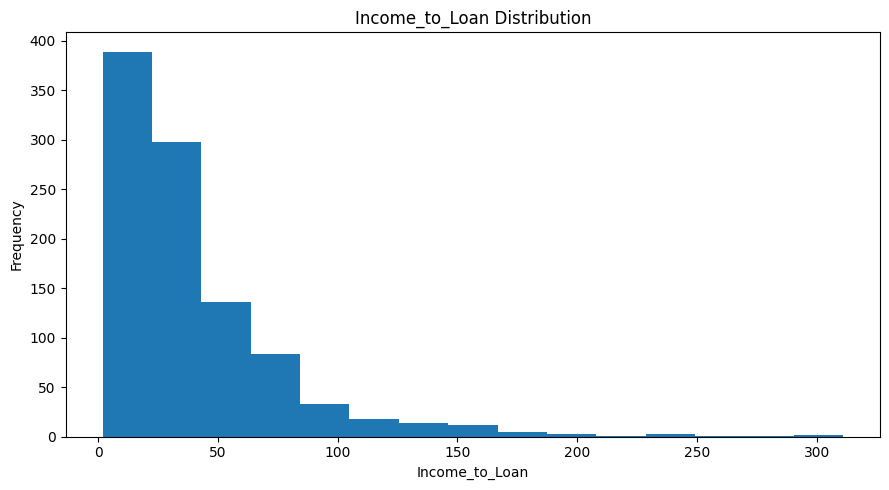

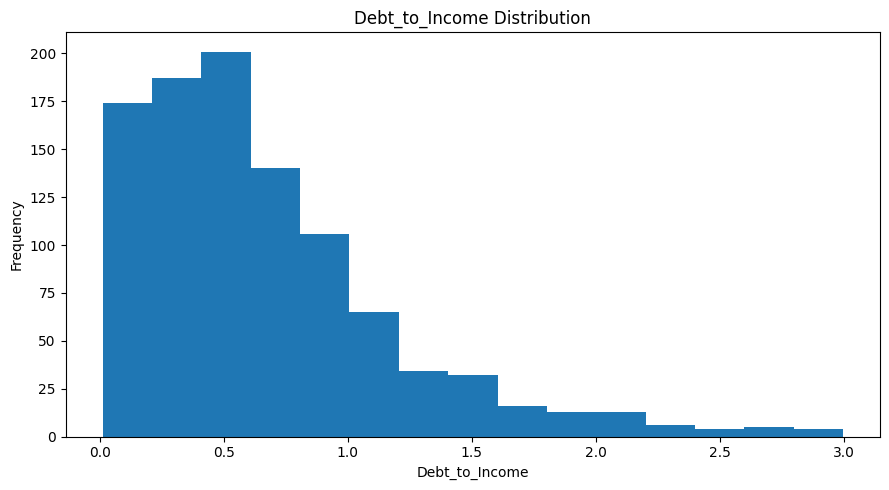

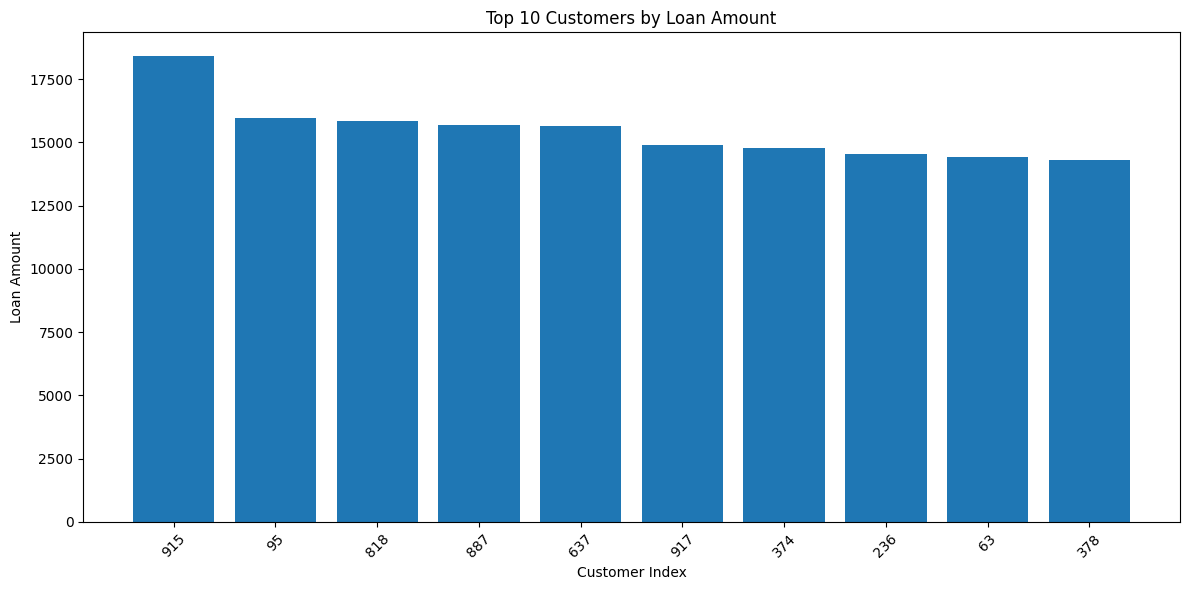

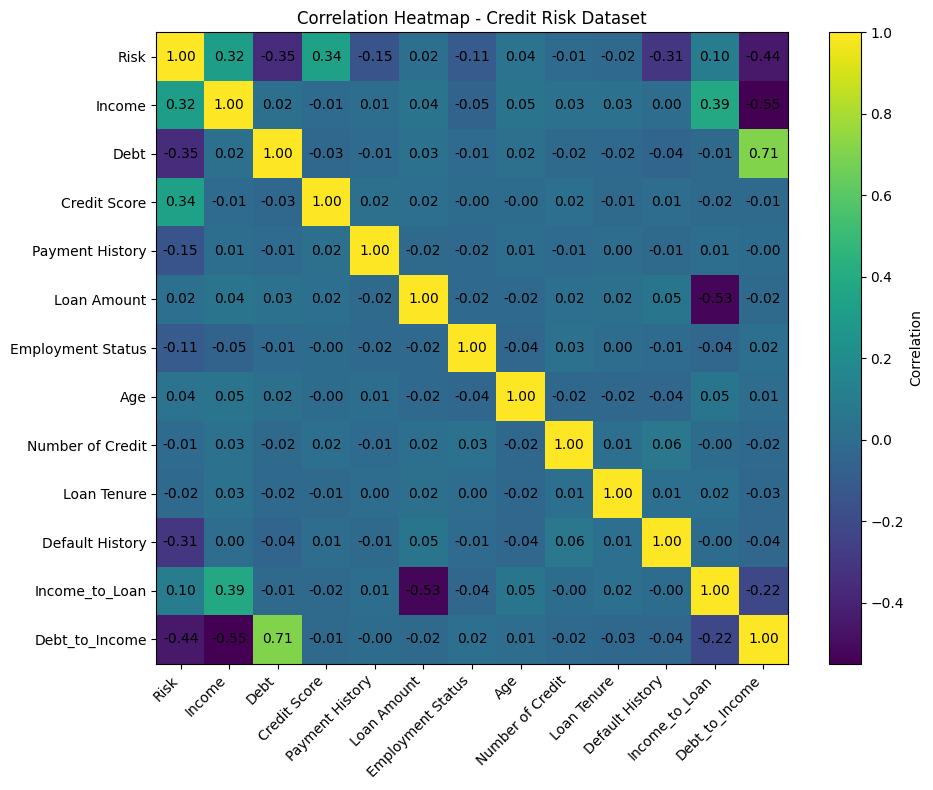

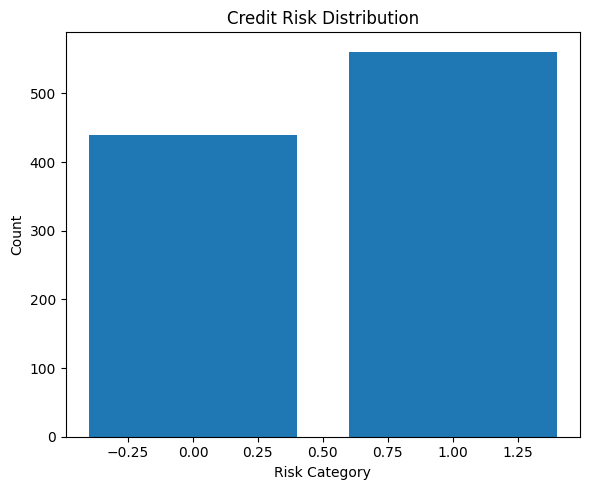

In [24]:

def plot_credit_numeric_eda_separate(df, save_dir="static"):

    os.makedirs(save_dir, exist_ok=True)

    # Select numeric columns
    num = df.select_dtypes(include=[np.number])
    
    # Histogram for Numeric Columns

    for col in num.columns:

        plt.figure(figsize=(9,5))

        plt.hist(num[col], bins=15)

        plt.title(f"{col} Distribution")

        plt.xlabel(col)

        plt.ylabel("Frequency")

        plt.tight_layout()

        plt.savefig(f"{save_dir}/{col}_hist.png")

        plt.show()

        plt.close()

    # Top 10 Customers by Loan Amount

    top10 = df.nlargest(10, "Loan Amount")

    plt.figure(figsize=(12,6))

    plt.bar(
        top10.index.astype(str),
        top10["Loan Amount"]
    )

    plt.xticks(rotation=45)

    plt.xlabel("Customer Index")

    plt.ylabel("Loan Amount")

    plt.title("Top 10 Customers by Loan Amount")

    plt.tight_layout()

    plt.savefig(f"{save_dir}/top10_loan_amount.png")

    plt.show()

    plt.close()

    # Correlation Heatmap

    corr = num.corr().values

    labels = num.columns

    plt.figure(figsize=(10,8))

    plt.imshow(corr)

    plt.colorbar(label="Correlation")

    plt.xticks(
        range(len(labels)),
        labels,
        rotation=45,
        ha="right"
    )

    plt.yticks(range(len(labels)), labels)

    # Correlation values inside heatmap
    for i in range(len(labels)):
        for j in range(len(labels)):
            plt.text(
                j,
                i,
                f"{corr[i, j]:.2f}",
                ha="center",
                va="center"
            )

    plt.title("Correlation Heatmap - Credit Risk Dataset")

    plt.tight_layout()

    plt.savefig(f"{save_dir}/correlation_heatmap.png")

    plt.show()

    plt.close()
 
    # Risk Count Plot

    if "Risk" in df.columns:

        risk_counts = df["Risk"].value_counts()

        plt.figure(figsize=(6,5))

        plt.bar(
            risk_counts.index,
            risk_counts.values
        )

        plt.xlabel("Risk Category")

        plt.ylabel("Count")

        plt.title("Credit Risk Distribution")

        plt.tight_layout()

        plt.savefig(f"{save_dir}/risk_distribution.png")

        plt.show()

        plt.close()


# Run Function

plot_credit_numeric_eda_separate(df)

In [25]:
def evaluate_model():
    predictions = model.predict(X_test)
    cm = confusion_matrix(y_test, predictions)
    print(cm)

In [26]:
df

,Risk,Income,Debt,Credit Score,Payment History,Loan Amount,Employment Status,Age,Number of Credit,Loan Tenure,Default History,Income_to_Loan,Debt_to_Income
0,0,36578,51714,402,0,1169,0,58,1,57,0,31.263248,1.413762
1,1,53110,53153,735,2,5951,1,51,1,35,0,8.923051,1.000791
2,0,93296,50591,570,2,2096,0,56,4,38,0,44.490224,0.542258
3,1,98542,8047,406,1,7882,0,39,6,57,0,12.500571,0.081660
4,0,26488,74831,371,1,4870,0,56,8,14,0,5.437898,2.824984
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,67053,20074,655,1,1736,0,33,4,16,0,38.602763,0.299371
996,0,39079,60841,340,1,3857,0,28,9,37,0,10.129342,1.556832
997,1,84223,39702,333,1,804,0,60,4,54,0,104.624845,0.471386
998,1,93497,13594,316,0,1845,0,24,5,12,0,50.648429,0.145393


# logistic regression model


In [28]:
# ==========================================
# PREDICTIONS
# ==========================================
predictions = model.predict(X_test)

print(predictions)

[1 1 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 0 0 0 1 1 0 0 0 1 0 1 0 1 0 1 1 0 1
 1 1 1 0 1 0 0 1 1 1 0 1 1 0 1 1 1 1 1 1 1 0 1 1 1 0 1 0 0 1 0 1 0 0 0 0 1
 1 0 0 0 1 1 1 1 1 0 1 0 1 0 1 1 0 1 1 1 1 0 0 1 1 0 0 1 1 1 1 1 1 0 1 0 0
 1 0 1 0 1 1 1 1 1 1 0 1 1 0 0 1 1 1 1 1 0 1 1 0 1 0 1 0 1 0 0 0 0 1 1 1 1
 0 0 1 0 0 1 1 0 0 1 0 0 0 0 1 0 0 1 1 0 1 1 0 1 0 1 1 1 0 1 1 1 0 1 0 1 0
 1 0 1 1 1 1 1 1 0 1 1 0 1 0 0]



===== Logistic Regression Results =====
Accuracy : 0.735
Precision: 0.7350427350427351
Recall   : 0.7962962962962963
F1-Score : 0.7644444444444445
ROC-AUC  : 0.729669887278583

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.66      0.70        92
           1       0.74      0.80      0.76       108

    accuracy                           0.73       200
   macro avg       0.73      0.73      0.73       200
weighted avg       0.73      0.73      0.73       200



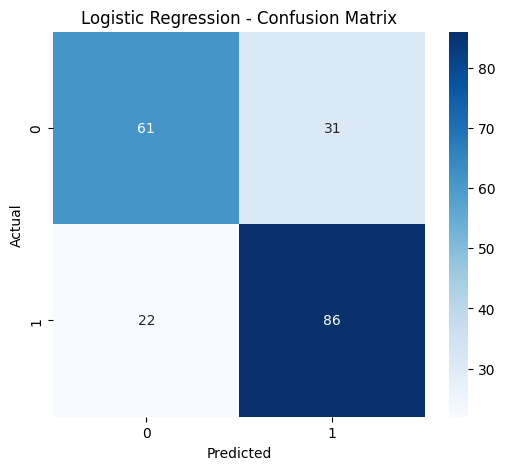

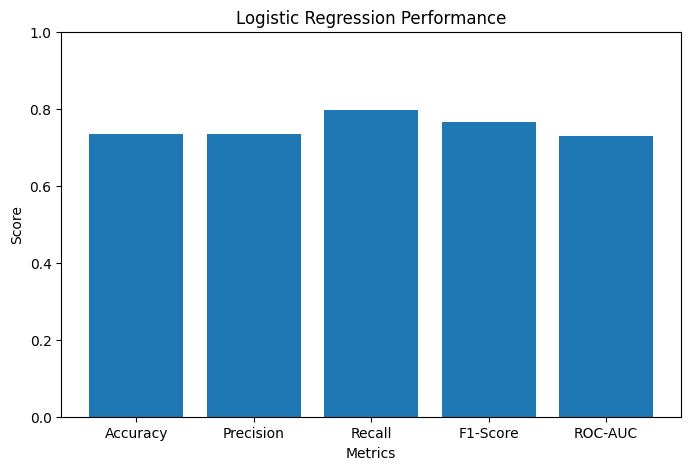

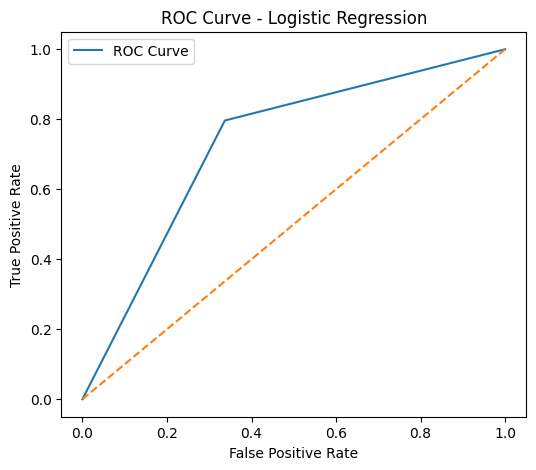

In [46]:


# ==========================================
# Evaluation Metrics
# ==========================================

accuracy = accuracy_score(y_test, predictions)

precision = precision_score(y_test, predictions)

recall = recall_score(y_test, predictions)

f1 = f1_score(y_test, predictions)

roc_auc = roc_auc_score(y_test, predictions)

# ==========================================
# Print Results
# ==========================================

print("\n===== Logistic Regression Results =====")

print("Accuracy :", accuracy)

print("Precision:", precision)

print("Recall   :", recall)

print("F1-Score :", f1)

print("ROC-AUC  :", roc_auc)

# ==========================================
# Classification Report
# ==========================================

print("\nClassification Report:")

print(classification_report(y_test, predictions))

# ==========================================
# Confusion Matrix Graph
# ==========================================

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Logistic Regression - Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

# ==========================================
# Metrics Bar Graph
# ==========================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

scores = [
    accuracy,
    precision,
    recall,
    f1,
    roc_auc
]

plt.figure(figsize=(8,5))

plt.bar(metrics, scores)

plt.ylim(0,1)

plt.xlabel("Metrics")

plt.ylabel("Score")

plt.title("Logistic Regression Performance")

plt.show()

# ==========================================
# ROC Curve
# ==========================================

fpr, tpr, thresholds = roc_curve(y_test, predictions)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="ROC Curve")

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Logistic Regression")

plt.legend()

plt.show()

# Decision tree 


===== Decision Tree Results =====
Accuracy : 0.815
Precision: 0.8380952380952381
Recall   : 0.8148148148148148
F1-Score : 0.8262910798122066
ROC-AUC  : 0.8150161030595814

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.82      0.80        92
           1       0.84      0.81      0.83       108

    accuracy                           0.81       200
   macro avg       0.81      0.82      0.81       200
weighted avg       0.82      0.81      0.82       200



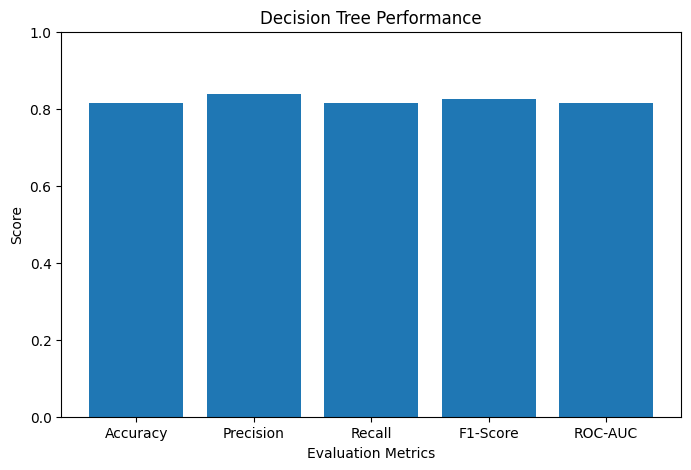

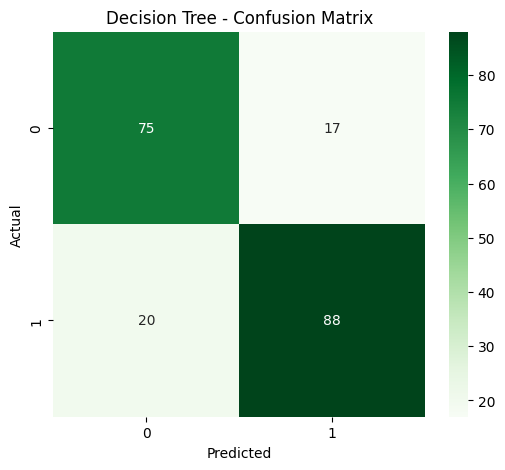

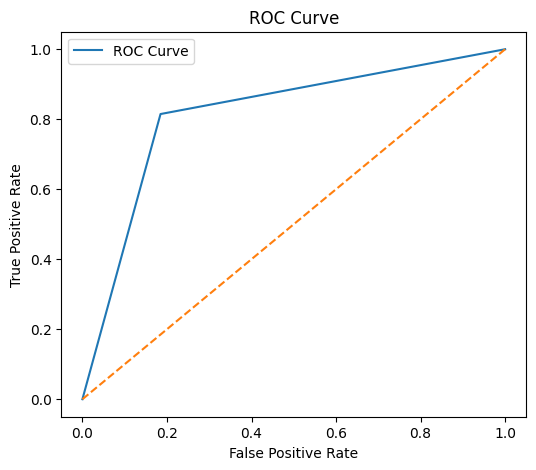

In [43]:
# ==========================================
# Decision Tree Classifier
# With Evaluation Graphs
# ==========================================

from sklearn.tree import DecisionTreeClassifier

# ==========================================
# Train Decision Tree Model
# ==========================================

dt_model = DecisionTreeClassifier()

dt_model.fit(X_train, y_train)

# ==========================================
# Predictions
# ==========================================

predictions = dt_model.predict(X_test)

# ==========================================
# Evaluation Metrics
# ==========================================

accuracy = accuracy_score(y_test, predictions)

precision = precision_score(y_test, predictions)

recall = recall_score(y_test, predictions)

f1 = f1_score(y_test, predictions)

roc_auc = roc_auc_score(y_test, predictions)

# ==========================================
# Print Results
# ==========================================

print("\n===== Decision Tree Results =====")

print("Accuracy :", accuracy)

print("Precision:", precision)

print("Recall   :", recall)

print("F1-Score :", f1)

print("ROC-AUC  :", roc_auc)

# ==========================================
# Classification Report
# ==========================================

print("\nClassification Report:")

print(classification_report(y_test, predictions))

# ==========================================
# Metrics Bar Graph
# ==========================================

metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score",
    "ROC-AUC"
]

scores = [
    accuracy,
    precision,
    recall,
    f1,
    roc_auc
]

plt.figure(figsize=(8,5))

plt.bar(metrics, scores)

plt.ylim(0,1)

plt.xlabel("Evaluation Metrics")

plt.ylabel("Score")

plt.title("Decision Tree Performance")

plt.show()

# ==========================================
# Confusion Matrix
# ==========================================

cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Decision Tree - Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
# ==========================================
# ROC Curve
# ==========================================
fpr, tpr, thresholds = roc_curve(y_test, predictions)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.show()



===== RANDOM FOREST RESULTS =====
Accuracy   : 0.9000
Precision  : 0.8860
Recall     : 0.9352
F1-Score   : 0.9099
ROC-AUC    : 0.9676

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.86      0.89        92
           1       0.89      0.94      0.91       108

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.90      0.90      0.90       200


Confusion Matrix:



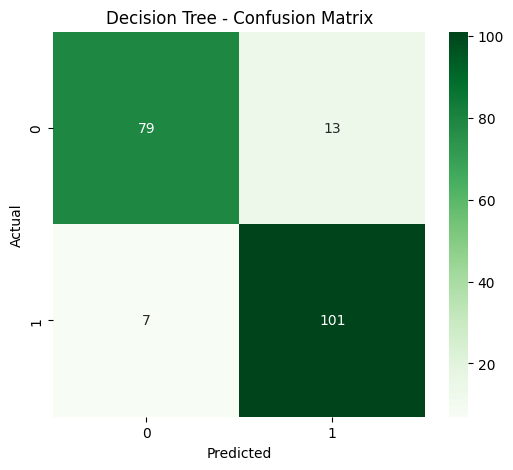

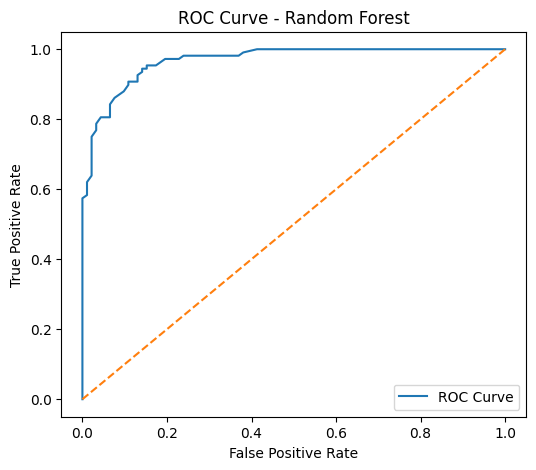

In [50]:

# ==========================================
# RANDOM FOREST MODEL
# ==========================================

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# TRAIN MODEL
model.fit(X_train, y_train)

# ==========================================
# PREDICTIONS
# ==========================================

predictions = model.predict(X_test)

# Probability values for ROC-AUC
y_prob = model.predict_proba(X_test)[:, 1]

# ==========================================
# EVALUATION METRICS
# ==========================================

accuracy = accuracy_score(y_test, predictions)
precision = precision_score(y_test, predictions)
recall = recall_score(y_test, predictions)
f1 = f1_score(y_test, predictions)
roc_auc = roc_auc_score(y_test, y_prob)

# ==========================================
# PRINT RESULTS
# ==========================================

print("\n===== RANDOM FOREST RESULTS =====")

print(f"Accuracy   : {accuracy:.4f}")
print(f"Precision  : {precision:.4f}")
print(f"Recall     : {recall:.4f}")
print(f"F1-Score   : {f1:.4f}")
print(f"ROC-AUC    : {roc_auc:.4f}")

# ==========================================
# CLASSIFICATION REPORT
# ==========================================

print("\nClassification Report:\n")
print(classification_report(y_test, predictions))

# ==========================================
# CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(y_test, predictions)

print("\nConfusion Matrix:\n")

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title("Decision Tree - Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()
y_prob = model.predict_proba(X_test)[:,1]

# ==========================================
# ROC CURVE
# ==========================================

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.show()

In [52]:
# ==========================================
# CONCLUSION
# ==========================================

print("""
Conclusion:

In this project, three machine learning algorithms were used:
1. Logistic Regression
2. Decision Tree
3. Random Forest

After evaluating the models using Accuracy, Precision,
Recall, F1-Score, and ROC-AUC metrics, the following
observations were made:

- Logistic Regression provided good baseline performance
  and worked well for linear relationships.

- Decision Tree captured nonlinear patterns better,
  but it may overfit the dataset.

- Random Forest achieved the best overall performance
  because it combines multiple decision trees and reduces
  overfitting.

Final Result:
Random Forest was the best model for credit risk prediction
because it produced higher Accuracy, Precision, Recall,
F1-Score, and ROC-AUC values compared to Logistic Regression
and Decision Tree.

Therefore, Random Forest is recommended for predicting
whether a customer has Good Risk or Bad Risk.
""")


Conclusion:

In this project, three machine learning algorithms were used:
1. Logistic Regression
2. Decision Tree
3. Random Forest

After evaluating the models using Accuracy, Precision,
Recall, F1-Score, and ROC-AUC metrics, the following
observations were made:

- Logistic Regression provided good baseline performance
  and worked well for linear relationships.

- Decision Tree captured nonlinear patterns better,
  but it may overfit the dataset.

- Random Forest achieved the best overall performance
  because it combines multiple decision trees and reduces
  overfitting.

Final Result:
Random Forest was the best model for credit risk prediction
because it produced higher Accuracy, Precision, Recall,
F1-Score, and ROC-AUC values compared to Logistic Regression
and Decision Tree.

Therefore, Random Forest is recommended for predicting
whether a customer has Good Risk or Bad Risk.

